
# Seasonal Biology in Multi-Omics Data  
## Session 1 — Data Reconstruction & Exploratory Seasonal Analysis

**Course:** Time Series in Biology & Medicine with python

---
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](
https://colab.research.google.com/github/ShamsaraE/time-series-medicine-biology-2026/blob/main/notebooks/01_Main_Project_MultiOmics_Seasonality.ipynb)
---

## Scientific Context

This notebook is based on the longitudinal study:

**Deep longitudinal multiomics profiling reveals two biological seasonal patterns in California**  
(*Nature Communications*)https://www.nature.com/articles/s41467-020-18758-1


Participants were followed over time and categorized into two groups:

- **IS — Insulin Sensitive**
- **IR — Insulin Resistant**

The central question:

> Does biological seasonality differ between IR and IS individuals?

In this session, we reconstruct the dataset and perform exploratory seasonal analyses.



# Data Components

You are provided with:

## (A) Omics Data Matrix

- Rows = samples (subject × visit)
- Columns = molecular features (genes, proteins, metabolites, etc.)

Dimension:

N_samples × P_features

## (B) Annotation Table (RNA_annotation_colData.csv)

Contains:

- Sample ID  
- Subject ID  
- Visit date  
- IR / IS classification  
- Clinical variables  

Time information is located in the annotation table and must be merged with the omics data.



# Session 1 Objectives

1. Reconstruct the longitudinal dataset  
2. Explore sampling frequency and visit structure  
3. Visualize temporal trajectories  
4. Compare IR vs IS groups descriptively  
5. Perform Winter vs Summer seasonal feature selection  

Session 2 will introduce harmonic and hierarchical modeling.



# Part 1 — Data Reconstruction

## Task 1.1

- Load omics matrix
- Load annotation table
- Merge using sample ID
- Convert date column to datetime
- Sort by subject and date

## Task 1.2 — Dataset Description

Report:

- Number of subjects
- Visits per subject
- Total time span
- Distribution of IR vs IS
- Missing visits

Questions:

- Is sampling regular?
- Is follow-up balanced?


In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import pandas as pd
import numpy as np

rna_path = "/content/drive/MyDrive/time_series_project/omics_data/RNA_df_Data.csv"
rna_data = pd.read_csv(rna_path)

rna_data.head()

,A1BG,A1BG.AS1,A1CF,A2M,A2M.AS1,A2ML1,A2MP1,AAED1,AAGAB,AAK1,...,ZSWIM5,ZSWIM7,ZSWIM8,ZSWIM8.AS1,ZXDA,ZXDB,ZXDC,ZYX,ZZEF1,ZZZ3
0,3.650804,0.000000,1.474314,9.828028,0.0,2.188093,6.061885,1.874904,1.874904,1.874904,...,0.917819,2.663468,6.950906,8.055275,0.917819,0.917819,0.0,1.874904,0.000000,1.474314
1,3.161285,1.758678,1.758678,9.847335,0.0,1.372536,6.148265,0.843683,2.528011,1.758678,...,2.314154,1.372536,6.779572,7.746544,0.843683,1.372536,0.0,2.528011,1.758678,1.758678
2,3.815272,2.346694,0.000000,9.865330,0.0,1.787409,5.779858,1.787409,0.861808,0.861808,...,0.861808,2.346694,6.016821,7.658636,1.787409,0.000000,0.0,2.093986,0.000000,0.861808
3,4.137146,1.507901,1.507901,10.531241,0.0,2.228948,6.939007,1.507901,3.353295,2.228948,...,2.228948,2.228948,7.562883,7.684254,0.000000,0.000000,0.0,2.707498,0.000000,1.507901
4,3.955534,1.692865,0.000000,9.138813,0.0,2.120840,4.853610,1.692865,0.000000,1.081674,...,0.000000,1.692865,4.908273,7.735612,1.081674,0.000000,0.0,0.000000,0.000000,1.081674


In [4]:
annot_path = "/content/drive/MyDrive/time_series_project/omics_data/RNA_annotation_colData.csv"
annot = pd.read_csv(annot_path)

annot.head()

,SubjectID,Date,IRIS,BMI,Time
0,ZOZOW1T,10-04-02 08:46:26,IS,21.47,92.0
1,ZOZOW1T,10-07-15 08:46:26,IS,21.47,196.0
2,ZOZOW1T,14-12-13 08:46:26,IS,21.47,347.0
3,ZOZOW1T,15-01-05 08:46:26,IS,21.47,5.0
4,ZOZOW1T,15-06-17 08:46:26,IS,21.47,168.0


In [5]:
# Merge
df = pd.concat([annot, rna_data], axis = 1)

df.head()

,SubjectID,Date,IRIS,BMI,Time,A1BG,A1BG.AS1,A1CF,A2M,A2M.AS1,...,ZSWIM5,ZSWIM7,ZSWIM8,ZSWIM8.AS1,ZXDA,ZXDB,ZXDC,ZYX,ZZEF1,ZZZ3
0,ZOZOW1T,10-04-02 08:46:26,IS,21.47,92.0,3.650804,0.000000,1.474314,9.828028,0.0,...,0.917819,2.663468,6.950906,8.055275,0.917819,0.917819,0.0,1.874904,0.000000,1.474314
1,ZOZOW1T,10-07-15 08:46:26,IS,21.47,196.0,3.161285,1.758678,1.758678,9.847335,0.0,...,2.314154,1.372536,6.779572,7.746544,0.843683,1.372536,0.0,2.528011,1.758678,1.758678
2,ZOZOW1T,14-12-13 08:46:26,IS,21.47,347.0,3.815272,2.346694,0.000000,9.865330,0.0,...,0.861808,2.346694,6.016821,7.658636,1.787409,0.000000,0.0,2.093986,0.000000,0.861808
3,ZOZOW1T,15-01-05 08:46:26,IS,21.47,5.0,4.137146,1.507901,1.507901,10.531241,0.0,...,2.228948,2.228948,7.562883,7.684254,0.000000,0.000000,0.0,2.707498,0.000000,1.507901
4,ZOZOW1T,15-06-17 08:46:26,IS,21.47,168.0,3.955534,1.692865,0.000000,9.138813,0.0,...,0.000000,1.692865,4.908273,7.735612,1.081674,0.000000,0.0,0.000000,0.000000,1.081674


In [10]:
# Date format needed to be fixed
#omics_data["Date"] = pd.to_datetime(omics_data["Date"], format='%y-%m-%d  %h:%m:%s', errors='coerce')

import numpy as np

df["date_raw"] = df["Date"].astype(str)

# first try YYYY-MM-DD
d1 = pd.to_datetime(df["date_raw"], format="%Y-%m-%d %H:%M:%S", errors="coerce")
d2 = pd.to_datetime(df["date_raw"], format="%Y-%m-%d", errors="coerce")

# then try YY-MM-DD
d3 = pd.to_datetime(df["date_raw"], format="%y-%m-%d %H:%M:%S", errors="coerce")
d4 = pd.to_datetime(df["date_raw"], format="%y-%m-%d", errors="coerce")

df["Date"] = d1.fillna(d2).fillna(d3).fillna(d4)
omics_data = df

In [11]:
df.head()

,SubjectID,Date,IRIS,BMI,Time,A1BG,A1BG.AS1,A1CF,A2M,A2M.AS1,...,ZSWIM7,ZSWIM8,ZSWIM8.AS1,ZXDA,ZXDB,ZXDC,ZYX,ZZEF1,ZZZ3,date_raw
0,ZOZOW1T,2010-04-02 08:46:26,IS,21.47,92.0,3.650804,0.000000,1.474314,9.828028,0.0,...,2.663468,6.950906,8.055275,0.917819,0.917819,0.0,1.874904,0.000000,1.474314,2010-04-02 08:46:26
1,ZOZOW1T,2010-07-15 08:46:26,IS,21.47,196.0,3.161285,1.758678,1.758678,9.847335,0.0,...,1.372536,6.779572,7.746544,0.843683,1.372536,0.0,2.528011,1.758678,1.758678,2010-07-15 08:46:26
2,ZOZOW1T,2014-12-13 08:46:26,IS,21.47,347.0,3.815272,2.346694,0.000000,9.865330,0.0,...,2.346694,6.016821,7.658636,1.787409,0.000000,0.0,2.093986,0.000000,0.861808,2014-12-13 08:46:26
3,ZOZOW1T,2015-01-05 08:46:26,IS,21.47,5.0,4.137146,1.507901,1.507901,10.531241,0.0,...,2.228948,7.562883,7.684254,0.000000,0.000000,0.0,2.707498,0.000000,1.507901,2015-01-05 08:46:26
4,ZOZOW1T,2015-06-17 08:46:26,IS,21.47,168.0,3.955534,1.692865,0.000000,9.138813,0.0,...,1.692865,4.908273,7.735612,1.081674,0.000000,0.0,0.000000,0.000000,1.081674,2015-06-17 08:46:26


In [12]:
print("Min:", df["Date"].min())
print("Max:", df["Date"].max())
print("Years covered:", df["Date"].dt.year.nunique())

Min: 2010-04-02 08:46:26
Max: 2016-12-20 08:46:26
Years covered: 7


In [13]:
print(omics_data["Date"].dtype)

datetime64[ns]


In [14]:
omics_data["Date_raw"] = omics_data["Date"]
omics_data["Date"] = omics_data["Date"].replace("NA", np.nan)

In [15]:
## Sorted Data by Subject ID and date
df = omics_data.sort_values(by=["SubjectID", "Date"]).reset_index(drop=True)

In [16]:
df.head(5)

,SubjectID,Date,IRIS,BMI,Time,A1BG,A1BG.AS1,A1CF,A2M,A2M.AS1,...,ZSWIM8,ZSWIM8.AS1,ZXDA,ZXDB,ZXDC,ZYX,ZZEF1,ZZZ3,date_raw,Date_raw
0,ZIS22OE,2013-07-11 08:46:26,NaN,NaN,192.0,4.939937,2.104154,2.572692,11.454062,0.000000,...,7.055047,7.805507,0.000000,0.000000,0.000000,2.104154,1.405844,0.000000,2013-07-11 08:46:26,2013-07-11 08:46:26
1,ZJTKAE3,2013-10-21 08:46:26,IR,31.24,294.0,4.929963,5.083722,0.753318,4.757839,7.095522,...,5.324917,7.491522,0.000000,2.354451,0.000000,1.245697,0.753318,0.000000,2013-10-21 08:46:26,2013-10-21 08:46:26
2,ZJTKAE3,2014-01-23 08:46:26,IR,31.24,23.0,5.147299,4.999812,2.541410,4.526162,7.265969,...,5.147299,7.673803,0.000000,0.000000,0.000000,2.151853,0.000000,0.755996,2014-01-23 08:46:26,2014-01-23 08:46:26
3,ZJTKAE3,2014-03-31 08:46:26,IR,31.24,90.0,4.619931,3.147786,0.000000,10.180884,0.000000,...,7.409843,7.814383,0.000000,2.302018,3.147786,2.302018,0.000000,2.302018,2014-03-31 08:46:26,2014-03-31 08:46:26
4,ZJTKAE3,2014-07-02 08:46:26,IR,31.24,183.0,5.712552,3.333047,2.009271,10.329752,0.000000,...,8.062151,8.216878,2.009271,0.000000,2.009271,2.009271,0.000000,0.000000,2014-07-02 08:46:26,2014-07-02 08:46:26


In [17]:
n_subjects = df["SubjectID"].nunique()
print ("Total Number of Subjects" , n_subjects)

Total Number of Subjects 102


In [18]:
# Visits per subject
visits_per_subject = df.groupby("SubjectID").size()

visits_per_subject

,0
SubjectID,
ZIS22OE,1
ZJTKAE3,14
ZJXC41N,20
ZK01UI6,1
ZK112BX,13
...,...
ZY9XQJP,7
ZYHHR4Z,27
ZYLJ7R7,9


In [19]:
# Visits per subject
visits_per_subject = df.groupby("SubjectID").size()

print("Average Visits per Subject:", visits_per_subject.mean())
print("Minimum Visits per Subject:", visits_per_subject.min())
print("Maximum Visits per Subject:", visits_per_subject.max())


Average Visits per Subject: 8.637254901960784
Minimum Visits per Subject: 1
Maximum Visits per Subject: 83


In [20]:
# Total time span
period_range = pd.period_range(
    start=df["Date"].min(),
    end=df["Date"].max(),
    freq="M"
)


print("Total Time Span:", len(period_range) , "months")

Total Time Span: 81 months


In [21]:
# Missing vists

nul_data = pd.isnull(df['SubjectID'])

df[nul_data]

,SubjectID,Date,IRIS,BMI,Time,A1BG,A1BG.AS1,A1CF,A2M,A2M.AS1,...,ZSWIM8,ZSWIM8.AS1,ZXDA,ZXDB,ZXDC,ZYX,ZZEF1,ZZZ3,date_raw,Date_raw
881,NaN,2015-09-15 08:46:26,IR,38.9,258.0,4.443663,2.290619,1.846034,9.1148,0.721396,...,6.215518,8.26922,1.200098,1.846034,0.0,0.721396,0.721396,1.200098,2015-09-15 08:46:26,2015-09-15 08:46:26


In [22]:
visits_per_subject = df.groupby("SubjectID").size()

subjects_one_visit = (visits_per_subject == 1).sum()

print("Subjects with only one visit:", subjects_one_visit)

Subjects with only one visit: 10


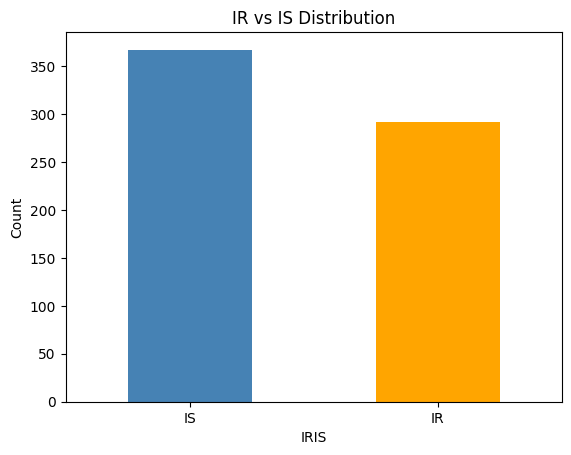

In [23]:
# Distribution of IR & IS

df["IRIS"].value_counts().plot(
    kind="bar",
    color=["steelblue", "orange"]
)

plt.ylabel("Count")
plt.title("IR vs IS Distribution")
plt.xticks(rotation=0)
plt.show()

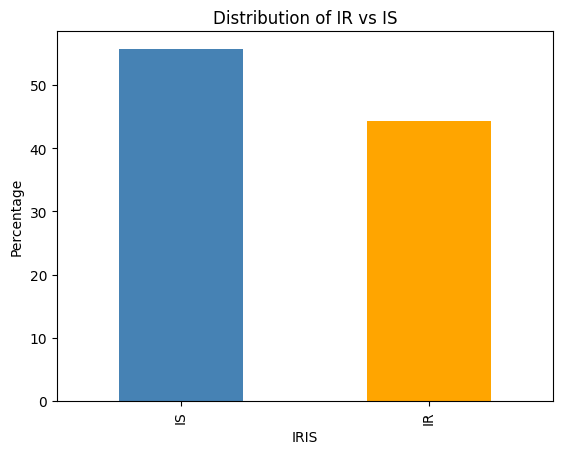

In [24]:
(df["IRIS"].value_counts(normalize=True) * 100).plot(kind="bar", color=["steelblue", "orange"])

plt.ylabel("Percentage")
plt.title("Distribution of IR vs IS")
plt.show()


# Part 2 — Exploratory Time Series Analysis

## Task 2.1 — Individual Trajectories

- Plot selected features over time
- Separate by subject
- Color by IR vs IS

Questions:

- Interpret your visualization

## Task 2.2 — Group Means

Compute group mean trajectories for IR and IS.

Questions:

- Do patterns differ between groups?


In [25]:
# Drop Null Values
df_clean = df.dropna()

print(f"Original shape: {df.shape}")
print(f"Shape after dropping any null: {df_clean.shape}")
print(f"Rows dropped: {len(df) - len(df_clean)}")

Original shape: (882, 10346)
Shape after dropping any null: (654, 10346)
Rows dropped: 228


In [26]:
df_clean.head()

,SubjectID,Date,IRIS,BMI,Time,A1BG,A1BG.AS1,A1CF,A2M,A2M.AS1,...,ZSWIM8,ZSWIM8.AS1,ZXDA,ZXDB,ZXDC,ZYX,ZZEF1,ZZZ3,date_raw,Date_raw
1,ZJTKAE3,2013-10-21 08:46:26,IR,31.24,294.0,4.929963,5.083722,0.753318,4.757839,7.095522,...,5.324917,7.491522,0.000000,2.354451,0.000000,1.245697,0.753318,0.000000,2013-10-21 08:46:26,2013-10-21 08:46:26
2,ZJTKAE3,2014-01-23 08:46:26,IR,31.24,23.0,5.147299,4.999812,2.541410,4.526162,7.265969,...,5.147299,7.673803,0.000000,0.000000,0.000000,2.151853,0.000000,0.755996,2014-01-23 08:46:26,2014-01-23 08:46:26
3,ZJTKAE3,2014-03-31 08:46:26,IR,31.24,90.0,4.619931,3.147786,0.000000,10.180884,0.000000,...,7.409843,7.814383,0.000000,2.302018,3.147786,2.302018,0.000000,2.302018,2014-03-31 08:46:26,2014-03-31 08:46:26
4,ZJTKAE3,2014-07-02 08:46:26,IR,31.24,183.0,5.712552,3.333047,2.009271,10.329752,0.000000,...,8.062151,8.216878,2.009271,0.000000,2.009271,2.009271,0.000000,0.000000,2014-07-02 08:46:26,2014-07-02 08:46:26
5,ZJTKAE3,2014-10-01 08:46:26,IR,31.24,274.0,3.844098,1.847195,0.800981,8.918436,0.455379,...,5.766716,7.933511,0.455379,0.800981,0.800981,2.345558,0.000000,0.800981,2014-10-01 08:46:26,2014-10-01 08:46:26


In [27]:
print("Min:", df_clean["Date"].min())
print("Max:", df_clean["Date"].max())
print("Years covered:", df_clean["Date"].dt.year.nunique())

Min: 2010-04-02 08:46:26
Max: 2016-12-20 08:46:26
Years covered: 7


In [28]:
df_clean["Date"].isna().sum()

np.int64(0)

In [29]:
df_clean["Date"].dtype

dtype('<M8[ns]')

In [30]:
n_subjects = df['SubjectID'].nunique()
print("Total Number of Subjects original data:", n_subjects)

Total Number of Subjects original data: 102


In [31]:
n_subjects = df_clean['SubjectID'].nunique()
print("Total Number of Subjects after removal of missing vlaues:", n_subjects)

Total Number of Subjects after removal of missing vlaues: 66


In [32]:
# Check of columns exist
columns_to_check = ["C2", "C9", "IL5", "SIGLEC15", "IL1RAP"]

for col in columns_to_check:
   matches = [col for col in df_clean.columns if "sub" in col.lower()]
   print(f"Columns containing '{col}':", matches)


Columns containing 'C2': ['SubjectID', 'SUB1']
Columns containing 'C9': ['SubjectID', 'SUB1']
Columns containing 'IL5': ['SubjectID', 'SUB1']
Columns containing 'SIGLEC15': ['SubjectID', 'SUB1']
Columns containing 'IL1RAP': ['SubjectID', 'SUB1']


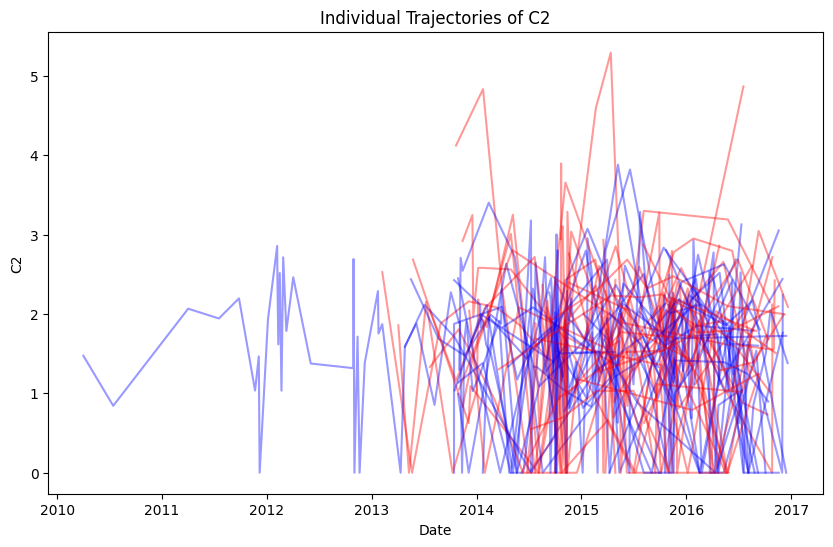

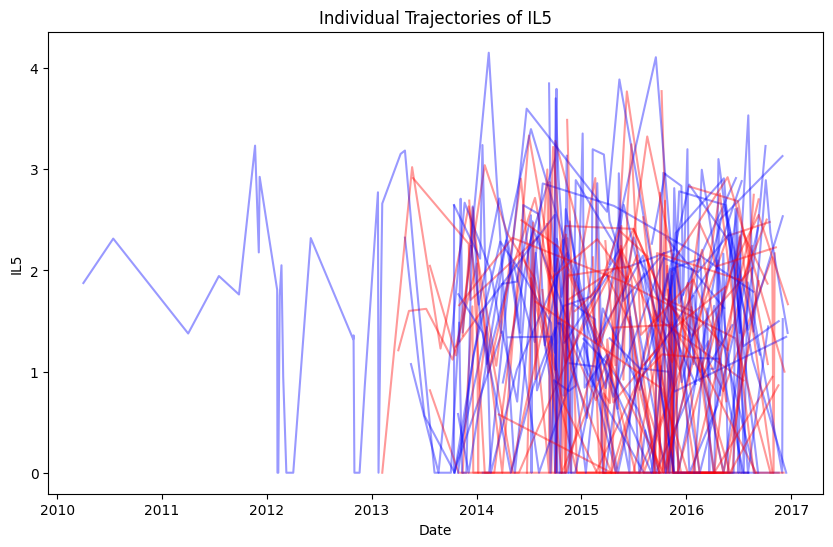

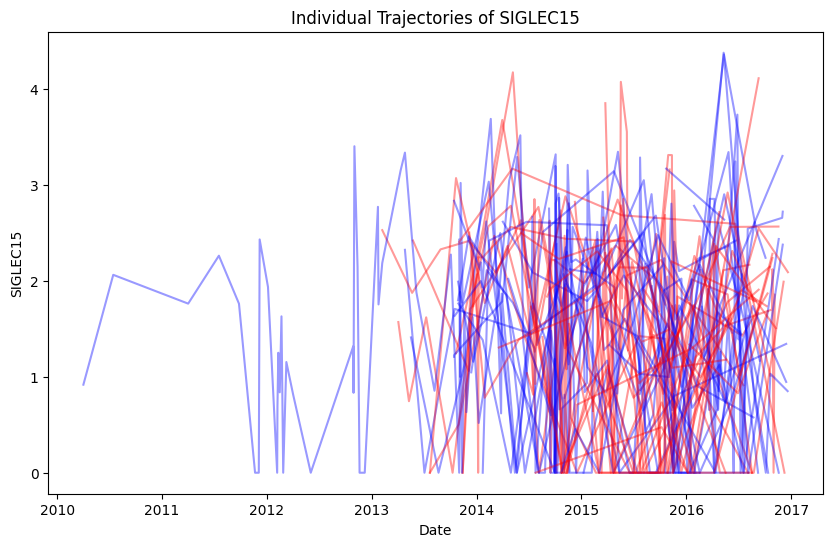

In [33]:
## Plot selected features over time
# Choose features to plot ("C2", "IL5", "SIGLEC15") based on paper
features = ["C2", "IL5", "SIGLEC15"]

for feature in features:

    plt.figure(figsize=(10,6))

    for subject in df_clean["SubjectID"].unique():

        sub_df = df_clean[df_clean["SubjectID"] == subject]

        # determine IR / IS group
        group = sub_df["IRIS"].iloc[0]
        color = "red" if group == "IR" else "blue"

        plt.plot(sub_df["Date"],
                 sub_df[feature],
                 color=color,
                 alpha=0.4)

    plt.title(f"Individual Trajectories of {feature}")
    plt.xlabel("Date")
    plt.ylabel(feature)
    plt.show()

In [34]:
# Random selection of a Subset
# randomly choose 10
subjects = df["SubjectID"].unique()
np.random.seed(42)
selected_subjects = np.random.choice(subjects, 10, replace=False)
selected_subjects
df_small = df_clean[df_clean["SubjectID"].isin(selected_subjects)]

In [35]:
##Plot the 10 subjects

plt.figure(figsize=(10,6))

for subject in selected_subjects:

    sub_df = df_small[df_small["SubjectID"] == subject]
    group = sub_df["IRIS"].iloc[0]

    color = "red" if group == "IR" else "blue"

    plt.plot(sub_df["Date"],
             sub_df["C9"],   # replace with your feature
             color=color,
             alpha=0.7)

plt.title("Random 10 Subjects")
plt.xlabel("Date")
plt.ylabel("C9")
plt.show()

IndexError: single positional indexer is out-of-bounds

<Figure size 1000x600 with 0 Axes>

In [ ]:
features = ["C2", "IL5", "SIGLEC15"]
for feature in features:

    plt.figure(figsize=(10,6))

    sns.lineplot(
        data=df_clean,
        x="Date",
        y=feature,
        hue="IRIS",
        estimator="mean",
        errorbar=None   )

    plt.title(f"Mean Trajectory of {feature} (IR vs IS)")
    plt.xlabel("Date")
    plt.ylabel(feature)
    plt.show()

In [ ]:
df_2018 = df[df["date"].dt.year == 2018]


# Part 3 — Feature Selection (IR vs IS)


Identify top features of each omic layer based on two groups (IR and IS) or for each group




# Part 4 — Seasonal Analysis

 for:

- IR group
- IS group

Is there any seasonality effect?
If there is, frequency and periodicity ?



# Part 5 - Cosine Similarity


Extract seasonal components
Or compute mean seasonal curves per group
Compare seasonal pattern of RNA vs Proteomics
Compare IR seasonal profile vs IS seasonal profile
Cluster features by seasonal pattern



# Deliverables

Submit:

- Clean notebook with outputs clear
- Clearly labeled figures
- Table of top seasonal features
- Statistical summaries
- 1–2 page interpretation

---

